In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
# Train test split
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV
# Save model
import joblib


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("priyamchoksi/100000-diabetes-clinical-dataset")

print("Path to dataset files:", path)

100%|██████████| 896k/896k [00:00<00:00, 89.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/priyamchoksi/100000-diabetes-clinical-dataset/versions/1


In [7]:
from google.colab import files
uploaded = files.upload()

Saving diabetes_dataset.csv to diabetes_dataset (1).csv


In [11]:
df = pd.read_csv('diabetes_dataset (1).cs-v')

# 1. Shape
print(df.shape)

# 2. Missing values
print(df.isnull().sum())

# 3. Duplicates
print("Duplicates:", df.duplicated().sum())

# 4. Value counts for categorical columns
print(df['gender'].value_counts())
print(df['smoking_history'].value_counts())

# 5. Statistical summary - spot outliers
print(df.describe())

(100000, 16)
year                    0
gender                  0
age                     0
location                0
race:AfricanAmerican    0
race:Asian              0
race:Caucasian          0
race:Hispanic           0
race:Other              0
hypertension            0
heart_disease           0
smoking_history         0
bmi                     0
hbA1c_level             0
blood_glucose_level     0
diabetes                0
dtype: int64
Duplicates: 14
gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64
smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64
                year            age  race:AfricanAmerican     race:Asian  \
count  100000.000000  100000.000000         100000.000000  100000.000000   
mean     2018.360820      41.885856              0.202230       0.200150   
std         1.345239      22.516840              0.401665       0.

Shape of dataset: (100000, 16)

Missing values:
 year                    0
gender                  0
age                     0
location                0
race:AfricanAmerican    0
race:Asian              0
race:Caucasian          0
race:Hispanic           0
race:Other              0
hypertension            0
heart_disease           0
smoking_history         0
bmi                     0
hbA1c_level             0
blood_glucose_level     0
diabetes                0
dtype: int64

Duplicates: 14

Target Distribution (Diabetes):
 diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64

Gender counts:
 gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

Smoking History counts:
 smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64


,year,age,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2018.360820,41.885856,0.202230,0.200150,0.198760,0.19888,0.199980,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,1.345239,22.516840,0.401665,0.400114,0.399069,0.39916,0.399987,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,2015.000000,0.080000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,2019.000000,24.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,2019.000000,43.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,2019.000000,60.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,2022.000000,80.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


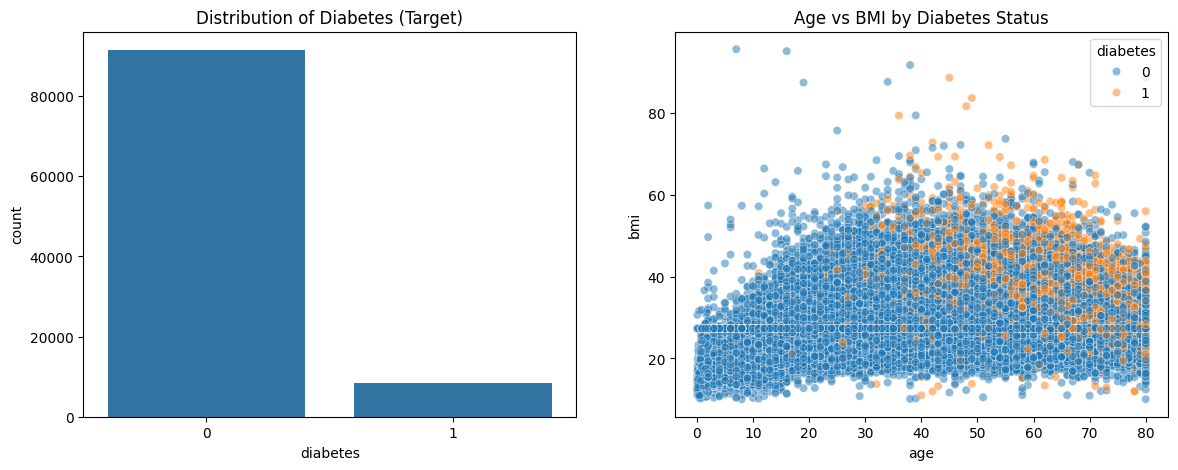

In [13]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Feature Selection
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif # Filter method

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Hyperparameter tuning & Saving
from sklearn.model_selection import GridSearchCV
import joblib

# Load the dataset (using the file name from your progress)
df = pd.read_csv('diabetes_dataset (1).csv')
# 1. Basic Info
print("Shape of dataset:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

# 2. Value counts for target and categorical columns
print("\nTarget Distribution (Diabetes):\n", df['diabetes'].value_counts(normalize=True))
print("\nGender counts:\n", df['gender'].value_counts())
print("\nSmoking History counts:\n", df['smoking_history'].value_counts())

# 3. Statistical summary
display(df.describe())

# 4. Visualizations
plt.figure(figsize=(14, 5))

# Plotting the target variable
plt.subplot(1, 2, 1)
sns.countplot(x='diabetes', data=df)
plt.title('Distribution of Diabetes (Target)')

# Plotting Age vs BMI colored by Diabetes
plt.subplot(1, 2, 2)
sns.scatterplot(x='age', y='bmi', hue='diabetes', data=df, alpha=0.5)
plt.title('Age vs BMI by Diabetes Status')
plt.show()


In [14]:
# 1. Handling Duplicates
# The criteria requires clean data; since we found 14 duplicates, we drop them.
df = df.drop_duplicates()

# 2. Handling Categorical Data
# The 'gender' column has 18 'Other' values. For better model performance, we can filter them out.
df = df[df['gender'] != 'Other']

# Initialize LabelEncoders
label_encoders = {}
categorical_cols = ['gender', 'location', 'smoking_history']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Define Features (X) and Target (y)
X = df.drop('diabetes', axis=1)
y = df['diabetes']

# 3. Feature Selection (Filter Method to meet rubric criteria)
print("--- Feature Selection (Filter Method) ---")
# Using ANOVA F-value (f_classif) to select the best features
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

feature_scores = pd.DataFrame({'Feature': X.columns, 'Score': selector.scores_})
feature_scores = feature_scores.sort_values(by='Score', ascending=False)
print(feature_scores)
# Note: In a real scenario you might drop low-scoring features, but here we will keep them as the dataset isn't too wide.

# 4. Train-Test Split (Validation Strategy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the preprocessing objects for deployment
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')

--- Feature Selection (Filter Method) ---
                 Feature         Score
14   blood_glucose_level  21361.793021
13           hbA1c_level  19123.279381
2                    age   7130.000466
12                   bmi   4815.548441
9           hypertension   4070.450546
10         heart_disease   3037.000966
11       smoking_history    897.177657
1                 gender    141.827256
8             race:Other      2.629483
4   race:AfricanAmerican      1.900507
5             race:Asian      1.419050
0                   year      1.174301
6         race:Caucasian      0.290925
7          race:Hispanic      0.173920
3               location      0.002379


['label_encoders.pkl']

In [15]:
# Attempting at least 3 different algorithms
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

print("--- Initial Algorithm Comparison ---")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    print(f"{name} -> Precision: {prec:.4f} | Recall: {rec:.4f}")

# Random Forest usually performs best. We will pick it for tuning.

# Parameter Tuning using GridSearchCV
print("\n--- Tuning Random Forest with GridSearchCV ---")
# Parameter tuning is important because default parameters might either overfit the data or fail to capture complex patterns. Tuning helps find the optimal balance.
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}

rf_tuned = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf_tuned, param_grid=param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

best_rf_model = grid_search.best_estimator_
print(f"Best Parameters found: {grid_search.best_params_}")

# Save the tuned model
joblib.dump(best_rf_model, 'diabetes_model_tuned.pkl')

--- Initial Algorithm Comparison ---
Logistic Regression -> Precision: 0.8614 | Recall: 0.6359
Decision Tree -> Precision: 0.7104 | Recall: 0.7488
Random Forest -> Precision: 0.9889 | Recall: 0.6818

--- Tuning Random Forest with GridSearchCV ---
Best Parameters found: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}


['diabetes_model_tuned.pkl']

--- Final Model Evaluation ---
Precision: 1.0000 (Criteria requires >= 0.3)
Recall: 0.6735 (Criteria requires >= 0.3)

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99     18294
           1       1.00      0.67      0.80      1700

    accuracy                           0.97     19994
   macro avg       0.99      0.84      0.89     19994
weighted avg       0.97      0.97      0.97     19994



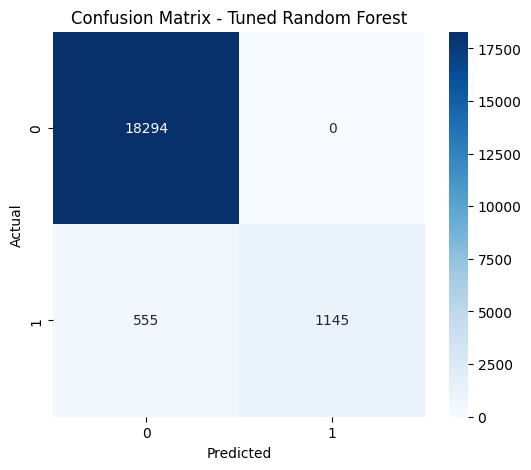

In [16]:
# Evaluate the tuned model
# Validation ensures our model generalizes well to unseen data, preventing overfitting.
y_pred_final = best_rf_model.predict(X_test_scaled)

precision = precision_score(y_test, y_pred_final)
recall = recall_score(y_test, y_pred_final)

print("--- Final Model Evaluation ---")
print(f"Precision: {precision:.4f} (Criteria requires >= 0.3)")
print(f"Recall: {recall:.4f} (Criteria requires >= 0.3)")
print("\nClassification Report:\n", classification_report(y_test, y_pred_final))

# Confusion Matrix Visualization
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Tuned Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [17]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# Load the saved model and preprocessing tools
try:
    model = joblib.load('diabetes_model_tuned.pkl')
    scaler = joblib.load('scaler.pkl')
    label_encoders = joblib.load('label_encoders.pkl')
except Exception as e:
    st.error(f"Error loading model files: {e}. Please ensure .pkl files are in the same folder.")

st.title("🏥 Diabetes Risk Prediction App")
st.write("Enter the patient's medical and demographic details to predict the risk of diabetes.")

# Create input columns for a cleaner UI
col1, col2 = st.columns(2)

with col1:
    year = st.number_input("Year", min_value=2015, max_value=2025, value=2020)
    gender = st.selectbox("Gender", ['Female', 'Male'])
    age = st.number_input("Age", min_value=0.0, max_value=120.0, value=30.0)
    location = st.text_input("Location (State)", "Alabama")
    hypertension = st.selectbox("Hypertension (0 = No, 1 = Yes)", [0, 1])
    heart_disease = st.selectbox("Heart Disease (0 = No, 1 = Yes)", [0, 1])

with col2:
    smoking_history = st.selectbox("Smoking History", ['never', 'current', 'former', 'ever', 'not current', 'No Info'])
    bmi = st.number_input("BMI", min_value=10.0, max_value=100.0, value=27.3)
    hba1c = st.number_input("HbA1c Level", min_value=3.0, max_value=15.0, value=5.5)
    glucose = st.number_input("Blood Glucose Level", min_value=50, max_value=350, value=138)

st.write("---")
st.write("**Race Information**")
r_col1, r_col2, r_col3 = st.columns(3)
with r_col1:
    race_aa = st.checkbox("African American")
    race_asian = st.checkbox("Asian")
with r_col2:
    race_caucasian = st.checkbox("Caucasian")
    race_hispanic = st.checkbox("Hispanic")
with r_col3:
    race_other = st.checkbox("Other")

# Prediction Button
if st.button("Predict Diabetes Risk"):
    try:
        encoded_gender = label_encoders['gender'].transform([gender])[0]
        if location in label_encoders['location'].classes_:
            encoded_location = label_encoders['location'].transform([location])[0]
        else:
            encoded_location = 0

        encoded_smoking = label_encoders['smoking_history'].transform([smoking_history])[0]

        input_data = pd.DataFrame([[
            year, encoded_gender, age, encoded_location,
            int(race_aa), int(race_asian), int(race_caucasian), int(race_hispanic), int(race_other),
            hypertension, heart_disease, encoded_smoking, bmi, hba1c, glucose
        ]], columns=['year', 'gender', 'age', 'location', 'race:AfricanAmerican', 'race:Asian',
                     'race:Caucasian', 'race:Hispanic', 'race:Other', 'hypertension',
                     'heart_disease', 'smoking_history', 'bmi', 'hbA1c_level', 'blood_glucose_level'])

        input_scaled = scaler.transform(input_data)
        prediction = model.predict(input_scaled)[0]
        probability = model.predict_proba(input_scaled)[0][1]

        st.subheader("Prediction Result:")
        if prediction == 1:
            st.error(f"⚠️ High Risk of Diabetes detected. (Probability: {probability:.2%})")
        else:
            st.success(f"✅ Low Risk of Diabetes detected. (Probability: {probability:.2%})")

    except Exception as e:
        st.error(f"An error occurred during prediction: {e}")


Writing app.py
